In [3]:
import pandas as pd
from shapely.geometry import Point
import datetime
import geopandas as gpd
import random
import numpy as np
import matplotlib.pyplot as plt

In [4]:
#Data Inspection
positives = pd.read_csv("../processed_data/positives.csv",  parse_dates=["DATETIME"])
positives.head()

,LAT,LON,DATETIME,TEMPERATURE,PERCIPITATION,WIND SPEED,RAIN,SNOWFALL,DISTRICT,CRIME HAPPENED
0,33.9825,-118.2695,2010-02-20 13:00:00,14.2,0.0,9.7,0.0,0.0,9,1
1,33.9599,-118.3962,2010-09-12 00:00:00,16.5,0.0,4.1,0.0,0.0,11,1
2,34.0224,-118.2524,2010-08-09 15:00:00,25.5,0.0,11.5,0.0,0.0,9,1
3,34.1016,-118.3295,2010-01-05 01:00:00,8.1,0.0,7.4,0.0,0.0,13,1
4,34.0387,-118.2488,2010-01-02 21:00:00,11.6,0.0,8.5,0.0,0.0,14,1


In [5]:
positives_gdf = gpd.GeoDataFrame(
    positives, 
    geometry=gpd.points_from_xy(positives['LON'], positives['LAT']),
    crs="EPSG:4326"
)

In [6]:
# Load LA City Council district boundaries from shapefile
districts_path = "../raw_data/LA_City_Council_Districts/LA_City_Council_Districts.shp"
districts = gpd.read_file(districts_path)
districts = districts.to_crs("EPSG:4326")

In [7]:
existing_set = set()

for _, row in positives.iterrows():
    dt = row['DATETIME']
    lat = round(row['LAT'], 4)
    lon = round(row['LON'], 4)
    
    key = (dt, lat, lon)
    existing_set.add(key)

In [8]:
# Flatten all polygons into a single MultiPolygon for easier sampling
la_polygons = districts['geometry'].union_all() 

negatives_set = []

def random_point_in_polygon(polygon):
    minx, miny, maxx, maxy = polygon.bounds
    while True:
        p = Point(random.uniform(minx, maxx), random.uniform(miny, maxy))
        if polygon.contains(p):
            return p

for _, row in positives.iterrows():
    while True:
        # Keep same date
        date_only = row['DATETIME'].date()
        
        # Random hour
        hour = np.random.randint(0, 24)
        dt_new = datetime.datetime.combine(date_only, datetime.time(hour, 0, 0))
        
        # Generate a random point inside LA districts
        point = random_point_in_polygon(la_polygons)
        new_lat, new_lon = point.y, point.x
        
        # Round for duplicate check
        key = (dt_new, round(new_lat, 4), round(new_lon, 4))
        if key not in existing_set:
            existing_set.add(key)
            negatives_set.append({
                'DATETIME': dt_new,
                'LAT': new_lat,
                'LON': new_lon,
                'CRIME HAPPENED': 0
            })
            break

In [9]:
negatives = pd.DataFrame(negatives_set)

In [10]:
negatives.head()

,DATETIME,LAT,LON,CRIME HAPPENED
0,2010-02-20 22:00:00,33.971657,-118.313224,0
1,2010-09-12 12:00:00,34.074193,-118.460474,0
2,2010-08-09 17:00:00,34.009022,-118.323385,0
3,2010-01-05 16:00:00,34.049717,-118.413323,0
4,2010-01-02 11:00:00,34.236798,-118.581298,0


In [11]:
negatives.shape

(207693, 4)

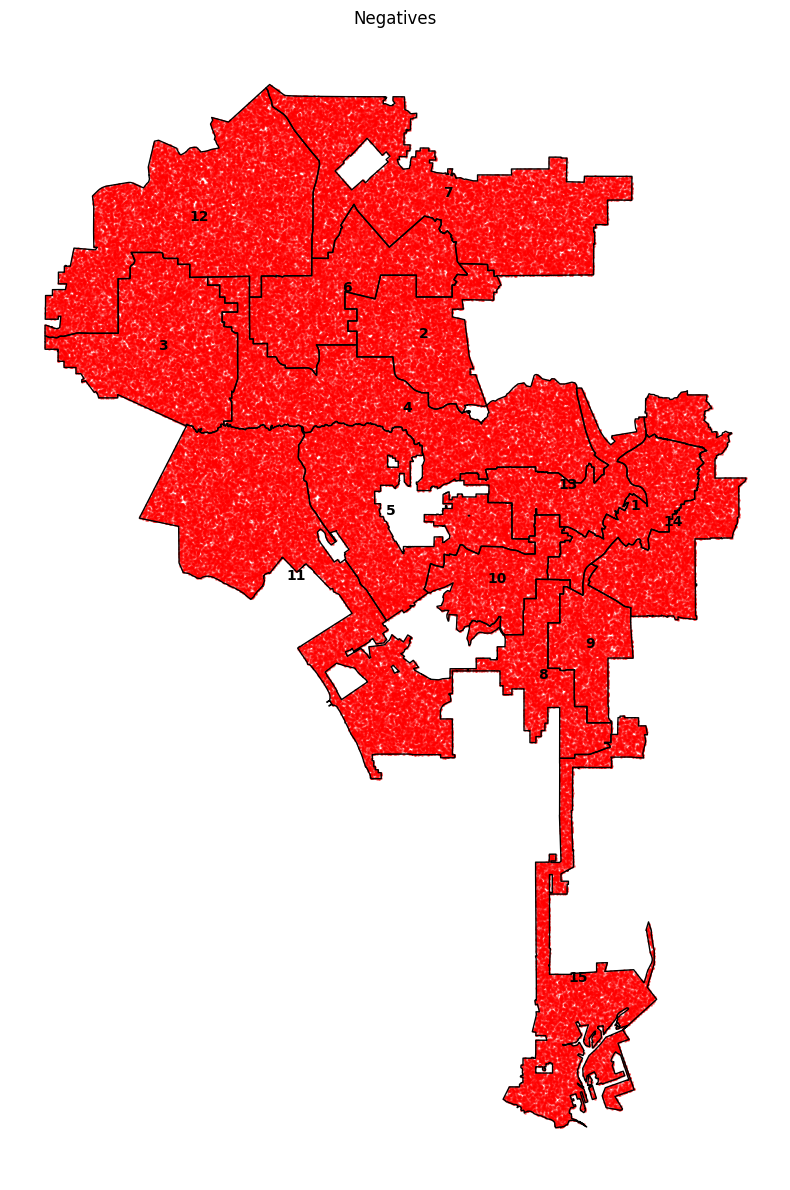

In [12]:
# Convert crime dataframe → GeoDataFrame
negatives_gdf = gpd.GeoDataFrame(
    negatives,
    geometry=gpd.points_from_xy(negatives["LON"], negatives["LAT"]),
    crs="EPSG:4326"
)

# Load LA City Council districts shapefile
districts_path = "../raw_data/LA_City_Council_Districts/LA_City_Council_Districts.shp"
districts_gdf = gpd.read_file(districts_path)

# Ensure same CRS
districts_gdf = districts_gdf.to_crs(negatives_gdf.crs)

fig, ax = plt.subplots(figsize=(12,12))

# Plot crime points
negatives_gdf.plot(
    ax=ax,
    markersize=1,
    alpha=0.4,
    color='red'
)

# Plot districts
districts_gdf.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1
)

# Add district labels
for _, row in districts_gdf.iterrows():
    centroid = row.geometry.centroid
    ax.text(
        centroid.x,
        centroid.y,
        str(int(row["DISTRICT"])),
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Negatives")
plt.axis("off")
plt.tight_layout()
plt.show()

In [13]:
# Perform spatial join, each point gets the polygon (district) it falls in
negatives_with_districts = gpd.sjoin(
    negatives_gdf, 
    districts_gdf[['DISTRICT', 'geometry']],
    how='left', 
    predicate='within'
)

In [14]:
negatives_with_districts.head()

,DATETIME,LAT,LON,CRIME HAPPENED,geometry,index_right,DISTRICT
0,2010-02-20 22:00:00,33.971657,-118.313224,0,POINT (-118.31322 33.97166),7,8
1,2010-09-12 12:00:00,34.074193,-118.460474,0,POINT (-118.46047 34.07419),4,5
2,2010-08-09 17:00:00,34.009022,-118.323385,0,POINT (-118.32338 34.00902),9,10
3,2010-01-05 16:00:00,34.049717,-118.413323,0,POINT (-118.41332 34.04972),4,5
4,2010-01-02 11:00:00,34.236798,-118.581298,0,POINT (-118.5813 34.2368),11,12


In [15]:
# Drop unnecessary columns from sjoin
negatives_with_districts = negatives_with_districts.drop(columns=['index_right', 'geometry'])

negatives_with_districts.head()

,DATETIME,LAT,LON,CRIME HAPPENED,DISTRICT
0,2010-02-20 22:00:00,33.971657,-118.313224,0,8
1,2010-09-12 12:00:00,34.074193,-118.460474,0,5
2,2010-08-09 17:00:00,34.009022,-118.323385,0,10
3,2010-01-05 16:00:00,34.049717,-118.413323,0,5
4,2010-01-02 11:00:00,34.236798,-118.581298,0,12


In [16]:
# Load LAPD divisions
lapd_gdf = gpd.read_file("../raw_data/LAPD_Division.geojson") 
lapd_gdf = lapd_gdf.to_crs("EPSG:4326")  # ensure same CRS as points

In [17]:
negatives_with_districts_gdf = gpd.GeoDataFrame(
    negatives_with_districts,
    geometry=gpd.points_from_xy(negatives_with_districts["LON"], negatives_with_districts["LAT"]),
    crs="EPSG:4326"
)

In [18]:
# Perform spatial join: each point gets the polygon (district) it falls in
negatives_with_districts_and_area = gpd.sjoin(
    negatives_with_districts_gdf, 
    lapd_gdf[['APREC', 'geometry']],
    how='left', 
    predicate='within'
)

In [19]:
negatives_with_districts_and_area.head()

,DATETIME,LAT,LON,CRIME HAPPENED,DISTRICT,geometry,index_right,APREC
0,2010-02-20 22:00:00,33.971657,-118.313224,0,8,POINT (-118.31322 33.97166),17.0,77TH STREET
1,2010-09-12 12:00:00,34.074193,-118.460474,0,5,POINT (-118.46047 34.07419),9.0,WEST LOS ANGELES
2,2010-08-09 17:00:00,34.009022,-118.323385,0,10,POINT (-118.32338 34.00902),14.0,SOUTHWEST
3,2010-01-05 16:00:00,34.049717,-118.413323,0,5,POINT (-118.41332 34.04972),9.0,WEST LOS ANGELES
4,2010-01-02 11:00:00,34.236798,-118.581298,0,12,POINT (-118.5813 34.2368),1.0,DEVONSHIRE


In [20]:
# Drop unnecessary columns from sjoin
negatives_with_districts_and_area = negatives_with_districts_and_area.drop(columns=['index_right', 'geometry'])

negatives_with_districts_and_area.head()

,DATETIME,LAT,LON,CRIME HAPPENED,DISTRICT,APREC
0,2010-02-20 22:00:00,33.971657,-118.313224,0,8,77TH STREET
1,2010-09-12 12:00:00,34.074193,-118.460474,0,5,WEST LOS ANGELES
2,2010-08-09 17:00:00,34.009022,-118.323385,0,10,SOUTHWEST
3,2010-01-05 16:00:00,34.049717,-118.413323,0,5,WEST LOS ANGELES
4,2010-01-02 11:00:00,34.236798,-118.581298,0,12,DEVONSHIRE


In [21]:
#Weather data
weather_data = pd.read_csv("../processed_data/weather_2010_2019_hourly.csv",  parse_dates=["datetime"])
weather_data.head()

,datetime,temperature,precipitation,wind_speed,rain,snowfall,APREC
0,2010-01-01 00:00:00,6.2,0.0,9.3,0.0,0.0,MISSION
1,2010-01-01 01:00:00,5.8,0.0,9.1,0.0,0.0,MISSION
2,2010-01-01 02:00:00,5.6,0.0,9.8,0.0,0.0,MISSION
3,2010-01-01 03:00:00,5.4,0.0,10.2,0.0,0.0,MISSION
4,2010-01-01 04:00:00,5.4,0.0,10.7,0.0,0.0,MISSION


In [22]:
# Merge on both datetime and area
negatives_with_districts_and_weather = pd.merge(
    negatives_with_districts_and_area,
    weather_data,
    left_on=['DATETIME', 'APREC'],
    right_on=['datetime', 'APREC'],
    how='left'  
)

In [23]:
negatives_with_districts_and_weather.head()

,DATETIME,LAT,LON,CRIME HAPPENED,DISTRICT,APREC,datetime,temperature,precipitation,wind_speed,rain,snowfall
0,2010-02-20 22:00:00,33.971657,-118.313224,0,8,77TH STREET,2010-02-20 22:00:00,11.2,0.0,3.9,0.0,0.0
1,2010-09-12 12:00:00,34.074193,-118.460474,0,5,WEST LOS ANGELES,2010-09-12 12:00:00,27.0,0.0,11.3,0.0,0.0
2,2010-08-09 17:00:00,34.009022,-118.323385,0,10,SOUTHWEST,2010-08-09 17:00:00,24.2,0.0,8.7,0.0,0.0
3,2010-01-05 16:00:00,34.049717,-118.413323,0,5,WEST LOS ANGELES,2010-01-05 16:00:00,20.2,0.0,9.1,0.0,0.0
4,2010-01-02 11:00:00,34.236798,-118.581298,0,12,DEVONSHIRE,2010-01-02 11:00:00,19.1,0.0,8.8,0.0,0.0


In [24]:
# Drop unnecessary columns
negatives_with_districts_and_weather.drop(columns=["datetime"], inplace=True)
negatives_with_districts_and_weather.drop(columns=["APREC"], inplace=True)

In [25]:
negatives_with_districts_and_weather.isna().sum()

DATETIME           0
LAT                0
LON                0
CRIME HAPPENED     0
DISTRICT           0
temperature       37
precipitation     37
wind_speed        37
rain              37
snowfall          37
dtype: int64

In [29]:
negatives_with_districts_and_weather = negatives_with_districts_and_weather.dropna()

In [30]:
negatives_with_districts_and_weather.isna().sum()

DATETIME          0
LAT               0
LON               0
CRIME HAPPENED    0
DISTRICT          0
TEMPERATURE       0
PERCIPITATION     0
WIND SPEED        0
RAIN              0
SNOWFALL          0
dtype: int64

In [31]:
negatives_with_districts_and_weather = negatives_with_districts_and_weather.rename(columns={"temperature": "TEMPERATURE"})
negatives_with_districts_and_weather = negatives_with_districts_and_weather.rename(columns={"precipitation": "PERCIPITATION"})
negatives_with_districts_and_weather = negatives_with_districts_and_weather.rename(columns={"wind_speed": "WIND SPEED"})
negatives_with_districts_and_weather = negatives_with_districts_and_weather.rename(columns={"rain": "RAIN"})
negatives_with_districts_and_weather = negatives_with_districts_and_weather.rename(columns={"snowfall": "SNOWFALL"})

In [32]:
negatives_with_districts_and_weather.head()

,DATETIME,LAT,LON,CRIME HAPPENED,DISTRICT,TEMPERATURE,PERCIPITATION,WIND SPEED,RAIN,SNOWFALL
0,2010-02-20 22:00:00,33.971657,-118.313224,0,8,11.2,0.0,3.9,0.0,0.0
1,2010-09-12 12:00:00,34.074193,-118.460474,0,5,27.0,0.0,11.3,0.0,0.0
2,2010-08-09 17:00:00,34.009022,-118.323385,0,10,24.2,0.0,8.7,0.0,0.0
3,2010-01-05 16:00:00,34.049717,-118.413323,0,5,20.2,0.0,9.1,0.0,0.0
4,2010-01-02 11:00:00,34.236798,-118.581298,0,12,19.1,0.0,8.8,0.0,0.0


In [33]:
# Export the processed DataFrame to CSV
negatives_with_districts_and_weather.to_csv("../processed_data/negatives.csv", index=False)